In [1]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import getpass

# Conexión a la base de datos
password = getpass.getpass("Introduce la contraseña MySQL: ")

conn = mysql.connector.connect(
    host="212.227.90.6",
    user="Equipo26",
    password=password,
    database="Equip_26"
)

df_alojamientos = pd.read_sql("SELECT * FROM copy_ta", conn)
conn.close()

print("Conexión exitosa ✅")
print(f"Datos cargados: {df_alojamientos.shape[0]} filas, {df_alojamientos.shape[1]} columnas")


C:\Users\ruben\AppData\Local\Temp\ipykernel_6208\3636638214.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_alojamientos = pd.read_sql("SELECT * FROM copy_ta", conn)


Conexión exitosa ✅
Datos cargados: 6733 filas, 37 columnas


## Análisis de negocio: Experiencia del Cliente

### Valoración Media

In [2]:
# Media general de todos los
df_filtrado = df_alojamientos[df_alojamientos['review_scores_rating_clean'].notna() & (df_alojamientos['review_scores_rating_clean'] >= 0)].copy()
df_filtrado['review_scores_rating_clean'].describe().round(2)

count    5459.00
mean       92.00
std         8.59
min        20.00
25%        89.00
50%        94.00
75%        98.00
max       100.00
Name: review_scores_rating_clean, dtype: float64

In [3]:
# Media de las valoraciones de los clientes por ciudad

resultado_describe = df_alojamientos[df_alojamientos['review_scores_rating_clean']>=0].groupby('city')['review_scores_rating_clean'].describe().round(2)
display(resultado_describe)

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
barcelona,1697.0,90.68,8.57,20.0,87.00,93.0,97.0,100.0
girona,754.0,91.13,10.84,20.0,88.00,94.0,99.0,100.0
madrid,1194.0,92.75,7.96,20.0,90.00,95.0,98.0,100.0
malaga,310.0,92.13,7.06,60.0,90.00,93.0,97.0,100.0
mallorca,794.0,93.44,8.84,20.0,90.00,96.0,100.0,100.0
menorca,116.0,93.47,6.18,75.0,89.75,95.0,99.0,100.0
sevilla,315.0,93.79,5.63,60.0,91.00,95.0,98.0,100.0
valencia,279.0,92.28,7.33,40.0,89.50,94.0,97.0,100.0


C:\Users\ruben\AppData\Local\Temp\ipykernel_6208\2474867554.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='city', y='review_scores_rating_clean', data=df_filtrado, palette='viridis')


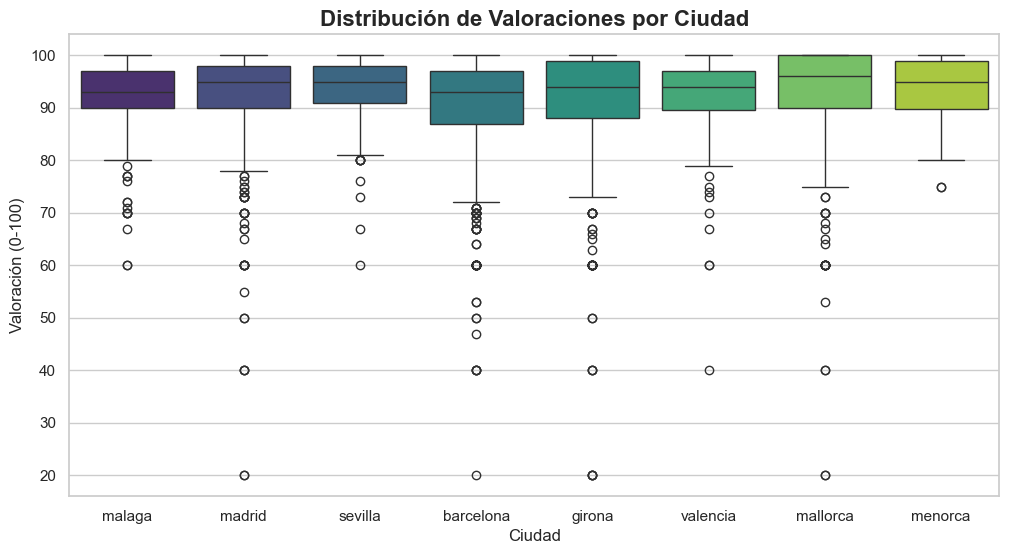

In [4]:

# Configuramos el estilo y el tamaño
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Creamos el boxplot
# Usamos df_filtrado porque ya tiene los nulos y valores negativos fuera
ax = sns.boxplot(x='city', y='review_scores_rating_clean', data=df_filtrado, palette='viridis')

# Añadimos títulos y etiquetas
plt.title('Distribución de Valoraciones por Ciudad', fontsize=16, fontweight='bold')
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Valoración (0-100)', fontsize=12)

# Opcional: Ajustar el rango del eje Y para ver mejor el detalle (ej: de 50 a 100)
# plt.ylim(50, 105) 

plt.show()

### Conclusiones: ###
• La nota de Barcelona es mucho más "sólida" y representativa. En Menorca, al haber pocos datos, cualquier mala experiencia individual puede hundir la media mucho más rápido.

• La métrica de desviación estándar identifica a Girona (10.84) y Barcelona (8.15) como los destinos con mayor heterogeneidad en sus calificaciones, contrastando con la consistencia observada en Madrid (6.99) y Sevilla (5.63).

• En Barcelona y Girona, el 25% de los alojamientos (percentil 25) están por debajo de 87-88. Incluso "lo peor" de Sevilla es mejor que la media de Barcelona.

• La visualización por Boxplot destaca la presencia de numerosos valores atípicos (outliers) en las grandes capitales como Madrid y Barcelona, con puntuaciones críticas que descienden hasta el 20/100. Esto demuestra que, a pesar de tener medias competitivas, estos destinos conviven con experiencias de cliente muy deficientes que no se observan en mercados más compactos como el de Menorca.

### Porcentaje de alojamientos que tienen una valoración >80 por ciudades

In [5]:
resultado_medias_ciudad = df_filtrado.groupby('city')['review_scores_rating_clean'].mean().round(2).sort_values(ascending=True)
total_por_ciudad = df_alojamientos[df_alojamientos['review_scores_rating_clean'].notna()].groupby('city')['apartment_id'].count()
total_por_ciudad
# 2. Agrupamos solo aquellos con nota superior a 80
mayor_80_por_ciudad = df_alojamientos[df_alojamientos['review_scores_rating_clean'] > 80].groupby('city')['apartment_id'].count()
mayor_80_por_ciudad
# # 3. Calculamos el porcentaje
# # Usamos .fillna(0) por si alguna ciudad no tiene ningún alojamiento > 80
porcentaje_mayor_80 = (mayor_80_por_ciudad / total_por_ciudad * 100).fillna(0).round(2)

# # 4. Consolidamos en una tabla resumen para el Analista
resumen_experiencia = pd.DataFrame({
    'Total Alojamientos': total_por_ciudad,
    'Alojamientos > 80': mayor_80_por_ciudad,
    'Media valoración' : resultado_medias_ciudad,
    'Porcentaje (%)': porcentaje_mayor_80
}).sort_values(by='Porcentaje (%)')

display(resumen_experiencia)

,Total Alojamientos,Alojamientos > 80,Media valoración,Porcentaje (%)
city,,,,
girona,754,635,91.13,84.22
barcelona,1697,1483,90.68,87.39
mallorca,794,720,93.44,90.68
malaga,310,282,92.13,90.97
valencia,279,257,92.28,92.11
madrid,1194,1104,92.75,92.46
menorca,116,108,93.47,93.10
sevilla,315,306,93.79,97.14


In [6]:
# 1. Calculamos el total global de alojamientos
total_global = resumen_experiencia['Total Alojamientos'].sum()

# 2. Calculamos el peso (proporción) de cada ciudad
resumen_experiencia['Peso'] = resumen_experiencia['Total Alojamientos'] / total_global

# 3. Para visualizarlo mejor, creamos una columna en porcentaje
resumen_experiencia['Peso (%)'] = (resumen_experiencia['Peso'] * 100).round(2)

# Mostramos el resultado ordenado de mayor a menor peso
display(resumen_experiencia[['Total Alojamientos', 'Peso', 'Peso (%)']].sort_values(by='Peso', ascending=False))

,Total Alojamientos,Peso,Peso (%)
city,,,
barcelona,1697,0.310863,31.09
madrid,1194,0.218721,21.87
mallorca,794,0.145448,14.54
girona,754,0.138121,13.81
sevilla,315,0.057703,5.77
malaga,310,0.056787,5.68
valencia,279,0.051108,5.11
menorca,116,0.021249,2.12


### KPI 4 (Andre)

In [8]:
# Unimos las tablas. Como 'city' es el índice en ambas, Pandas las alineará perfectamente.
df_analisis_final = resumen_dimensiones.merge(resumen_experiencia[['Peso']], left_index=True, right_index=True)

# Opcional: ver cómo ha quedado la unión
display(df_analisis_final.head())

# 1. Definimos las columnas de valoraciones (asegúrate de que los nombres coinciden)
# Definimos las columnas de notas (usando la lista que ya creaste)
dimensiones = [
    'review_scores_rating_clean', 'review_scores_cleanliness', 
    'review_scores_checkin', 'review_scores_communication', 
    'review_scores_location', 'review_scores_value', 'review_scores_accuracy'
]

# Calculamos la media ponderada para cada dimensión
resultados_espana = {}

for col in dimensiones:
    # Multiplicamos la nota de la ciudad por su peso y sumamos
    nota_ponderada = (df_analisis_final[col] * df_analisis_final['Peso']).sum()
    resultados_espana[col] = round(nota_ponderada, 2)

# Convertimos a Serie para una visualización limpia
media_espana_ponderada = pd.Series(resultados_espana, name="Media Ponderada Total España")

display(media_espana_ponderada)

NameError: name 'resumen_dimensiones' is not defined

### Conclusiones: ###
El rendimiento de Barcelona y Girona contrasta negativamente con el resto de ciudades, al registrar los porcentajes de excelencia más bajos (87.39% y 84.22%). Esta falta de consistencia penaliza la fiabilidad del destino y evidencia una brecha de calidad que compromete la experiencia del usuario.

### Diagnóstico de la Correlación entre Renting general, Higiene, Valor y Fidelidad del Anuncio ###

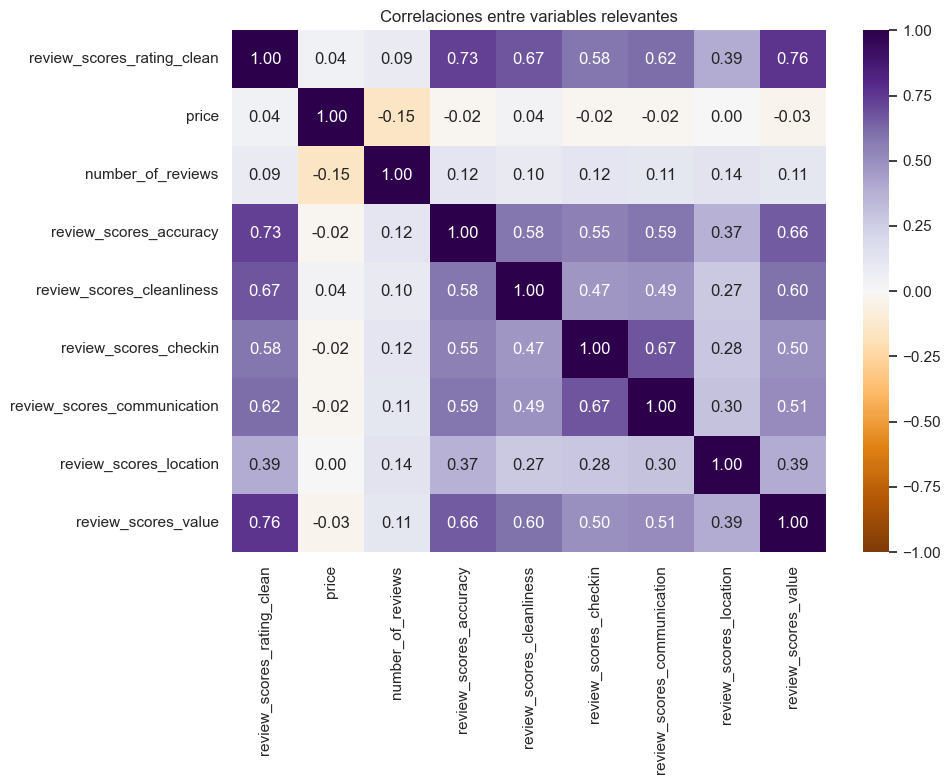

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
columnas_corr = [
    'review_scores_rating_clean', 'price', 'number_of_reviews',
    'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication',
    'review_scores_location', 'review_scores_value'
]

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_filtrado[columnas_corr].corr(),
    annot=True,
    fmt='.2f',
    cmap='PuOr',
    vmin=-1,
    vmax=1
)
plt.title("Correlaciones entre variables relevantes")
plt.tight_layout()
plt.show()

In [8]:
# 1. Definimos las columnas de las dimensiones (asegúrate de que los nombres coinciden con tu DB)
dimensiones = [ 
    'review_scores_rating_clean',
    'review_scores_cleanliness', 
    'review_scores_checkin', 
    'review_scores_communication', 
    'review_scores_location', 
    'review_scores_value', 
    'review_scores_accuracy'
]

# 2. Calculamos las medias por ciudad, multiplicando por 10 para comparar con el Rating (0-100)
# Usamos df_filtrado para mantener la limpieza que ya hicimos
resumen_dimensiones = df_filtrado.groupby('city')[dimensiones].mean()

# 3. Redondeamos y ordenamos (opcionalmente por la dimensión que más te interese, ej: value)
resumen_dimensiones = resumen_dimensiones.round(2).sort_values(by='review_scores_value', ascending=False)

display(resumen_dimensiones)

,review_scores_rating_clean,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,review_scores_accuracy
city,,,,,,,
sevilla,93.79,95.90,97.65,97.40,96.70,93.46,96.57
madrid,92.75,93.76,96.66,96.82,96.57,92.49,95.20
valencia,92.28,93.15,96.67,97.10,95.34,92.15,95.88
mallorca,93.44,94.62,97.06,97.04,94.35,91.99,95.11
malaga,92.13,94.23,96.45,96.68,94.58,91.77,95.06
barcelona,90.68,92.04,95.63,95.60,95.09,90.45,93.31
menorca,93.47,92.16,96.75,97.76,94.91,90.44,96.29
girona,91.13,91.71,95.45,96.11,94.48,90.27,93.84


### Conclusiones: ### 
• En review_scores_checkin, review_scores_communication y review_scores_location las medias que presentan BCN y Girona son altas y similares a las demás, por lo tanto, descartamos que estas sean las causantes.

• En review_scores_cleanliness (limpieza), review_scores_value (Relación Calidad-Precio) y review_scores_accuracy (Fidelidad) tienen una media por debajo de las demás ciudades. Además, como hemos apreciado en matriz de correlaciones
son las variables que presentan una correlación (0.67, 0.76 y 0.73) más elevado con respectoa a la variable de análisis review_scores_rating_clean.

### Ahora centramos nuestro análisis en las valoraciones de Cleanliness Value y Accurazy ###

In [9]:
# 1. Definimos las ciudades y las variables que queremos analizar
ciudades = ['barcelona', 'girona', 'sevilla']
vars_criticas = ['review_scores_cleanliness', 'review_scores_value', 'review_scores_accuracy']

# 2. Filtramos el DataFrame original y agrupamos por ciudad
# .describe() calcula automáticamente: count, mean, std, min, 25%, 50%, 75% y max
resumen = df_filtrado[df_filtrado['city'].isin(ciudades)].groupby('city')[vars_criticas].describe()

# 3. Seleccionamos solo las métricas que aparecen en tu imagen y en ese orden
columnas_interes = ['mean', 'min', '25%', '50%', '75%', 'max']
resumen_final = resumen.loc[:, (slice(None), columnas_interes)]

# 4. Transponemos la tabla para que las ciudades queden arriba (columnas) 
# y las métricas a la izquierda (filas), igual que en tu captura
tabla_lista = resumen_final.T

# Mostramos el resultado
display(tabla_lista)

city                             barcelona      girona     sevilla
review_scores_cleanliness mean   92.035398   91.710875   95.904762
                          min    20.000000   20.000000   60.000000
                          25%    90.000000   90.000000   90.000000
                          50%    90.000000  100.000000  100.000000
                          75%   100.000000  100.000000  100.000000
                          max   100.000000  100.000000  100.000000
review_scores_value       mean   90.449438   90.267023   93.460317
                          min    20.000000   20.000000   60.000000
                          25%    90.000000   90.000000   90.000000
                          50%    90.000000   90.000000   90.000000
                          75%   100.000000  100.000000  100.000000
                          max   100.000000  100.000000  100.000000
review_scores_accuracy    mean   93.313644   93.840000   96.571429
                          min    20.000000   20.000000   50.000000
                          25%    90.000000   90.000000   90.000000
                          50%   100.000000  100.000000  100.000000
                          75%   100.000000  100.000000  100.000000
                          max   100.000000  100.000000  100.000000

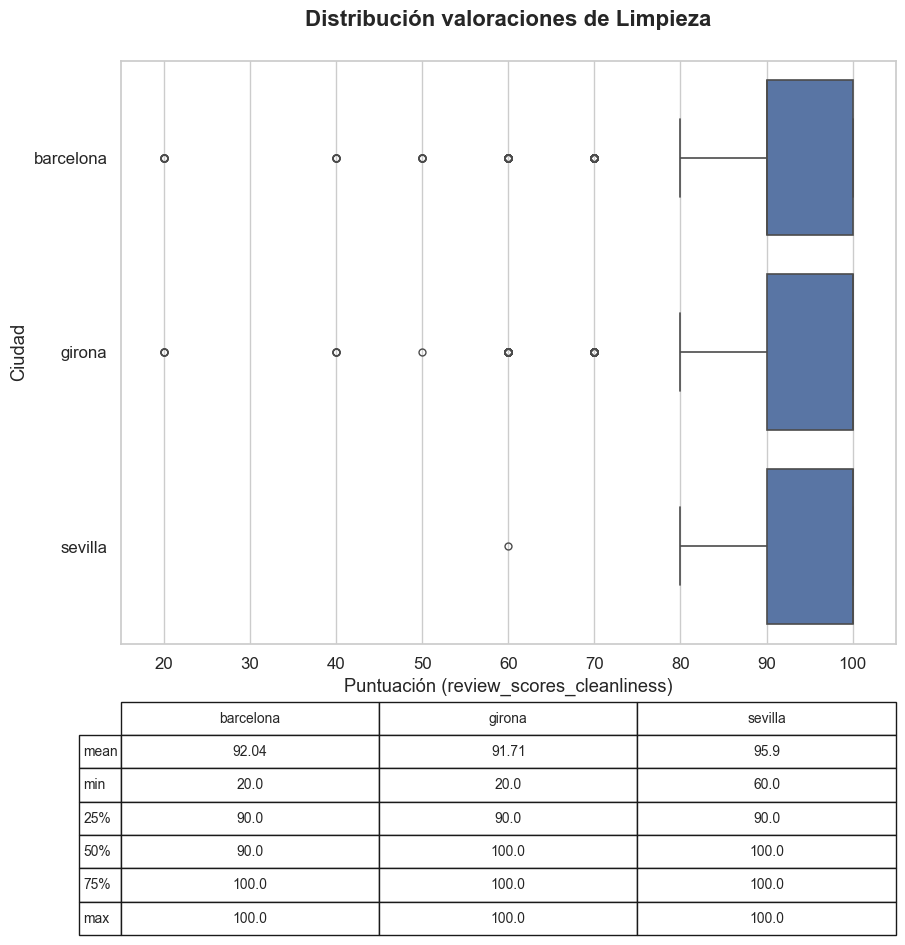

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuración de estilo global (para que sea más "bonito" pero honesto)
sns.set_theme(style="whitegrid", font_scale=1.1)

# 2. Extraemos los datos para la tabla inferior (usando tu objeto 'tabla_lista')
stats_plot = tabla_lista.loc['review_scores_cleanliness']

# 3. Configuración de la figura
fig, ax = plt.subplots(figsize=(10, 11)) # Un poco más alta
plt.subplots_adjust(bottom=0.35) # Espacio para la tabla

# 4. Dibujamos el Boxplot REAL (Sin el parámetro 'whis')
# El comportamiento por defecto (whis=1.5) mostrará los outliers
sns.boxplot(
    data=df_filtrado[df_filtrado['city'].isin(ciudades)], 
    y='city', 
    x='review_scores_cleanliness', 
    order=ciudades,
    # whis=[0, 100],  <-- ESTO ES LO QUE HEMOS QUITADO PARA VER LOS OUTLIERS
    ax=ax, 
    linewidth=1.2, # Líneas más finas para mayor precisión visual
    fliersize=5    # Tamaño de los puntos outliers
)

# 5. Insertamos la tabla (Mismo código de antes)
tabla = ax.table(
    cellText=stats_plot.round(2).values,
    rowLabels=stats_plot.index,
    colLabels=stats_plot.columns,
    cellLoc='center',
    loc='bottom',
    bbox=[0.0, -0.5, 1.0, 0.4] 
)

# Estética de la tabla
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 1.7) 

# 6. Títulos y etiquetas potentes
ax.set_title('Distribución valoraciones de Limpieza', pad=25, fontsize=16, fontweight='bold')
ax.set_xlabel('Puntuación (review_scores_cleanliness)')
ax.set_ylabel('Ciudad')

# 7. Ajuste de ejes para ver el outlier de 20
ax.set_xlim(15, 105) # Empezamos un poco antes del 20 para que se vea bien

plt.show()

### Conclusiones: ### 

Barcelona y Girona presentan una vulnerabilidad crítica en sus estándares de limpieza en comparación con Sevilla. Mientras que el mercado sevillano muestra una calidad compacta y predecible (con un suelo de 60 puntos), los mercados catalanes exhiben una alta variabilidad y una preocupante falta de control en el segmento de baja calidad, con valores extremos (outliers) que caen hasta los 20 puntos.

El dato más revelador es que Barcelona presenta una mediana de 90 puntos, la más baja de la comparativa. Esto transforma la experiencia del visitante en una "lotería de higiene": mientras que en Sevilla o Girona lo más probable es encontrar un alojamiento impecable (mediana de 100), en Barcelona el 50% de la oferta se sitúa en un aprobado raspado o notable bajo. Esta combinación de una mediana mediocre con outliers de 20 puntos evidencia que en la ciudad condal no existe un estándar mínimo garantizado, exponiendo al sector a un riesgo reputacional constante.

### Conclusiones: ###

Limpieza: 

• BCN: El análisis comparativo de medias y cuartiles identifica la limpieza como el principal cuello de botella estratégico. 
Mientras que la ciudad rinde a niveles de excelencia en hospitalidad y ubicación, su mediana de limpieza (90.0) revela que el 50% 
de su oferta no alcanza el estándar de higiene total. 
Centrar el análisis en esta variable es prioritario, ya que es el factor operativo que más castiga la reputación 
del destino y lo aleja de los niveles de excelencia de ciudades competidoras como Sevilla.

• Girona: Presenta una contradicción única: tiene una mediana de 100 en limpieza (lo cual es excelente), pero su media es la más baja (91.71).
No hace falta mejorar a todos los anfitriones (la mayoría ya son perfectos), sino identificar y penalizar o eliminar del mercado a ese pequeño porcentaje de alojamientos que ofrecen condiciones de higiene deplorables. 

Value y Accuracy:

• La existencia de alojamientos con puntuaciones tan extremadamente bajas (un 2 sobre 10) en Barcelona y Girona penaliza de forma desproporcionada el cálculo de la media de la ciudad. Sevilla no tiene esa "cola" de experiencias desastrosas que lastren su promedio.



In [11]:
# Creamos una máscara para alojamientos con puntuaciones bajas (< 90)
df_bajos = df_filtrado[
    (df_filtrado['review_scores_value'] < 90) | 
    (df_filtrado['review_scores_accuracy'] < 90) | 
    (df_filtrado['review_scores_cleanliness'] < 90)
]

# Agrupamos por ciudad para ver cuántos hay
conteo_bajos = df_bajos.groupby('city').size().reset_index(name='alojamientos_criticos')

# Calculamos el total de alojamientos por ciudad para sacar el porcentaje
total_ciudad = df_filtrado[df_filtrado['city'].isin(ciudades)].groupby('city').size().reset_index(name='total_alojamientos')

# Unimos y calculamos el %
analisis_lastre = conteo_bajos.merge(total_ciudad, on='city')
analisis_lastre['porcentaje_critico'] = (analisis_lastre['alojamientos_criticos'] / analisis_lastre['total_alojamientos'] * 100).round(2)

display(analisis_lastre.sort_values(by='porcentaje_critico', ascending=False))

,city,alojamientos_criticos,total_alojamientos,porcentaje_critico
1,girona,232,754,30.77
0,barcelona,469,1697,27.64
2,sevilla,35,315,11.11


### Conclusiones: ###

En Girona (30.77%) y Barcelona (27.64%), casi 1 de cada 3 alojamientos tienen unos estándares de calidad por debajo de puntuaciones inferiores a 90 en limpieza, valor o veracidad. 
Esto contrasta drásticamente con Sevilla, donde solo el 11.11% de la oferta cae en este rango. 
Esto explica por qué las medias de las ciudades catalanas son inferiores

### Influenye el precio en las valoraciones? ###


In [12]:
# 1. Definimos las variables incluyendo el precio
vars_analisis = ['price', 'review_scores_cleanliness', 'review_scores_value', 'review_scores_accuracy']

# 2. Generamos el descriptivo completo
resumen_stats = df_filtrado[df_filtrado['city'].isin(ciudades)].groupby('city')[vars_analisis].describe()

# 3. Seleccionamos las métricas clave para la comparativa
metricas = ['mean', 'min', '50%', 'max']
tabla_comparativa = resumen_stats.loc[:, (slice(None), metricas)].T

# Mostramos la tabla
display(tabla_comparativa)

city                              barcelona       girona      sevilla
price                     mean   842.125000  1144.086022   918.849840
                          min     80.000000   100.000000   150.000000
                          50%    600.000000   900.000000   690.000000
                          max   5000.000000  5000.000000  5000.000000
review_scores_cleanliness mean    92.035398    91.710875    95.904762
                          min     20.000000    20.000000    60.000000
                          50%     90.000000   100.000000   100.000000
                          max    100.000000   100.000000   100.000000
review_scores_value       mean    90.449438    90.267023    93.460317
                          min     20.000000    20.000000    60.000000
                          50%     90.000000    90.000000    90.000000
                          max    100.000000   100.000000   100.000000
review_scores_accuracy    mean    93.313644    93.840000    96.571429
                          min     20.000000    20.000000    50.000000
                          50%    100.000000   100.000000   100.000000
                          max    100.000000   100.000000   100.000000

### Conclusiones: ###

Los datos revelan que la menor puntuación media de Barcelona y Girona no se debe a sus altos precios.


### Analizando con profundidad la limpieza ###
<span style="font-size: 1.5em;">Miramos las variables que condicionan las valoraciones en limpieza. Hacemos la matriz de correlaciones de esta con variables que consideramos que pueden influir</span>

<span style="font-size: 1.5em;">Análisis BCN</span>

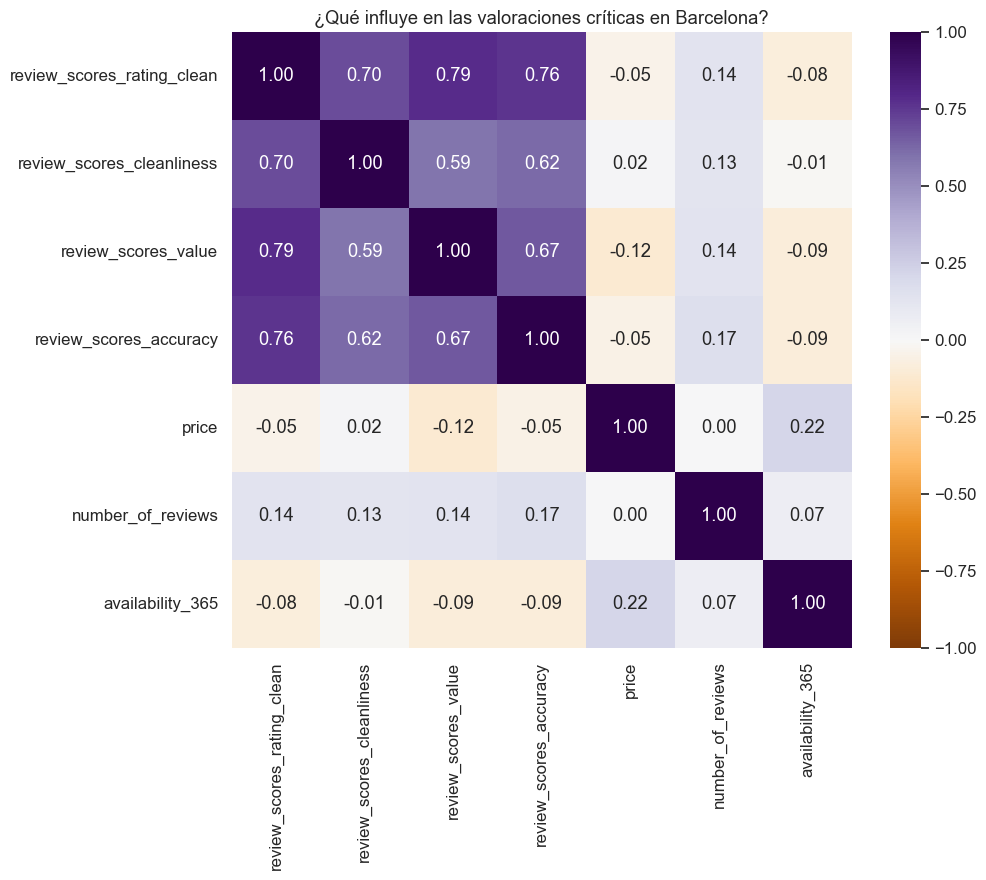

In [24]:
# Seleccionamos las críticas y añadimos variables de contexto (ejemplo)
vars_contexto = ['review_scores_rating_clean','review_scores_cleanliness', 'review_scores_value', 'review_scores_accuracy', 
                 'price', 'number_of_reviews', 'availability_365'] 

# Calculamos la matriz para una ciudad específica (ej. Barcelona)
corr_bcn = df_filtrado[df_filtrado['city'] == 'barcelona'][vars_contexto].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_bcn, 
            annot=True, 
            cmap='PuOr', 
            vmax=1, 
            vmin=-1, 
            fmt=".2f")
plt.title('¿Qué influye en las valoraciones críticas en Barcelona?')
plt.show()

### Conclusiones: ###
<span style="font-size: 1.5em;">En Barcelona, el precio no tiene un impacto real en la satisfacción del cliente (r = -0.05), lo que significa que bajar o subir las tarifas no arreglará las puntuaciones. 
El dato clave es que la limpieza actúa como un motor que arrastra a las otras dos valoraciones críticas: si el alojamiento está sucio, el cliente siente automáticamente que el anuncio le ha engañado 
($r = 0.76$) y que la relación calidad-precio es mala ($r = 0.79$).
Por tanto, la clave para subir la nota de la ciudad es centrarse exclusivamente en que los alojamientos estén impecables.</span>

<span style="font-size: 1.5em;">Análisis Girona</span>

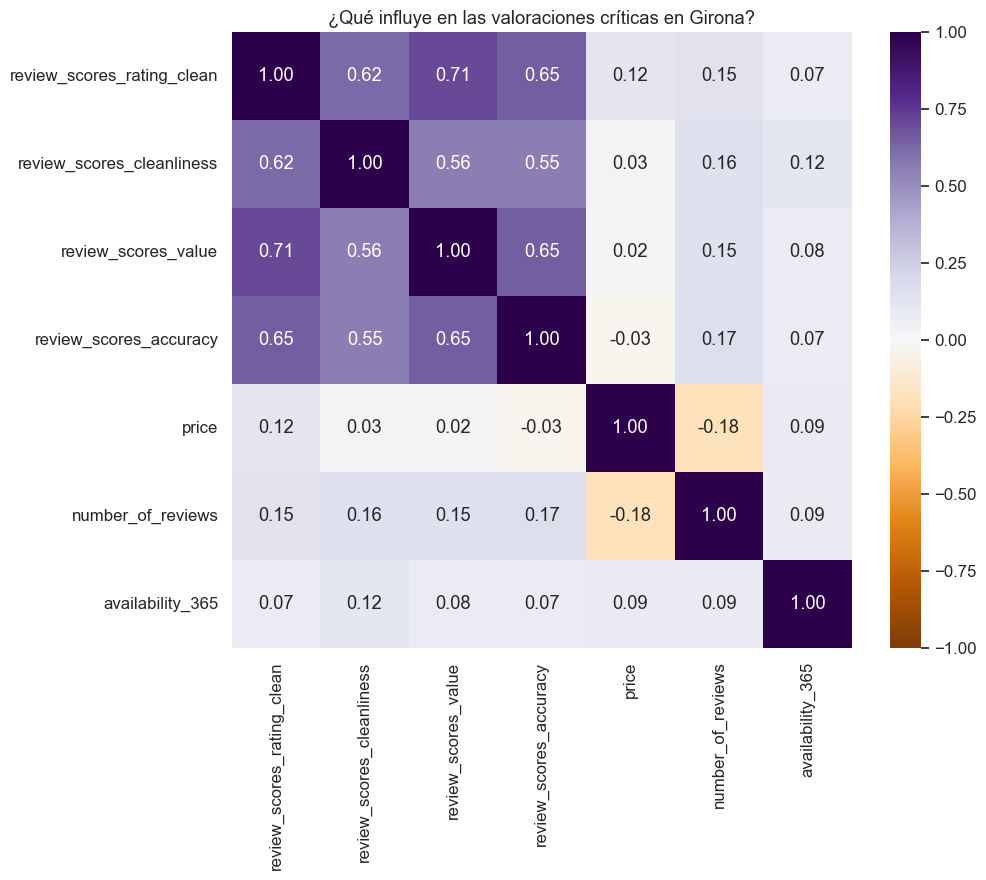

In [23]:
vars_contexto = ['review_scores_rating_clean','review_scores_cleanliness', 'review_scores_value', 'review_scores_accuracy', 
                 'price', 'number_of_reviews', 'availability_365'] 

# Calculamos la matriz para una ciudad específica (ej. Barcelona)
corr_gir = df_filtrado[df_filtrado['city'] == 'girona'][vars_contexto].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_gir, 
            annot=True, 
            cmap='PuOr', 
            vmax=1, 
            vmin=-1, 
            fmt=".2f")
plt.title('¿Qué influye en las valoraciones críticas en Girona?')
plt.show()

### Conclusiones: ###
<span style="font-size: 1.5em;">Al igual, para mejorar la reputación de Girona, el enfoque no debe estar en bajar los precios, sino en asegurar que la limpieza sea excelente, ya que es el factor que realmente define si el cliente se siente satisfecho o engañado</span>

### Conclusiones generales: ###
<span style="font-size: 1.5em;"> El análisis comparativo de las matrices de correlación de Barcelona y Girona confirma que la limpieza es la causa raíz que condiciona el resto de valoraciones de los huéspedes. Con coeficientes de hasta 0.7 en Barcelona y 0.62 en Girona, se evidencia una relación de causalidad donde la higiene actúa como el factor determinante de la experiencia: una deficiencia en este estándar provoca que el cliente perciba que el anuncio ha omitido la realidad del alojamiento —hundiendo la puntuación de veracidad (accuracy)— y que el precio pagado no se justifica —degradando la percepción de valor (value)—. Por tanto, los bajos resultados en estas categorías no son problemas independientes, sino consecuencias directas de una gestión de limpieza mejorable. Esto justifica que los esfuerzos estratégicos de la compañía deban centrarse en elevar los estándares de higiene, ya que es la vía principal para corregir el impacto negativo en la reputación global y mejorar simultáneamente la confianza y el valor percibido en ambos mercados  </span>

